# XGBoost SO2 Forecasting Model
## COS40007 Design Project - Smart Government
### Topic: Modeling Industrial Air Quality - Forecasting SO2 Emissions using IPI and Electricity Data

| Item | Detail |
|---|---|
| Model | XGBoost (Extreme Gradient Boosting) |
| Target Variable (Y) | air_so2 - Sulfur Dioxide level |
| Predictor Variables (X) | ipi_growth_yoy_index_sa, electricity_local |
| Data | Monthly, Jan 2018 to Dec 2022 (60 rows) |
| Evaluation Metrics | RMSE, MAE, R-squared |

Folder structure:
```
ASSIGNMENT/
    data/
        combined_air_electricity_ipi_cleaned.csv
        XGBoost.ipynb
```

## Section 1 - Library Imports

In [23]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

from xgboost import XGBRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from matplotlib.patches import Patch

print('All libraries loaded successfully.')

All libraries loaded successfully.


## Section 2 - Configuration

This is the only cell that needs to be edited if the filename or column names change. The notebook builds the file path relative to its own location, so it works as long as both the notebook and the CSV are inside the data folder.

In [24]:
# File path - the CSV is stored in COS40007DataCleaning
NOTEBOOK_DIR = os.path.dirname(os.path.abspath('__file__'))
FILE_NAME    = 'combined_air_electricity_ipi_cleaned.csv'
FILE_PATH    = os.path.join(NOTEBOOK_DIR, '..', 'COS40007DataCleaning', FILE_NAME)

# Column names
COL_DATE   = 'date'
COL_TARGET = 'air_so2'                 # Y  - Sulfur Dioxide (target to forecast)
COL_IPI    = 'ipi_growth_yoy_index_sa' # X1 - IPI year-on-year growth (seasonally adjusted)
COL_ELEC   = 'electricity_local'       # X2 - Local electricity consumption

# Model settings
N_LAGS      = 3     # Lag window in months (3 is appropriate for a 60-row dataset)
TRAIN_RATIO = 0.80  # 80% train, 20% test
RANDOM_SEED = 42

# Verify file exists before continuing
if os.path.exists(FILE_PATH):
    print('CSV found:', FILE_PATH)
else:
    print('ERROR: CSV not found at:', FILE_PATH)
    print('Make sure combined_air_electricity_ipi_cleaned.csv is in COS40007DataCleaning.')

CSV found: d:\Year 3 Sem 1\COS40007 AI Engineering\Assignment\XGBoost\..\COS40007DataCleaning\combined_air_electricity_ipi_cleaned.csv


## Section 3 - Load Dataset

In [25]:
df_raw = pd.read_csv(FILE_PATH, parse_dates=[COL_DATE])
df_raw = df_raw.sort_values(COL_DATE).reset_index(drop=True)
df_raw.set_index(COL_DATE, inplace=True)

# Keep only the three columns used in this model
df = df_raw[[COL_TARGET, COL_IPI, COL_ELEC]].copy()

print('Dataset loaded successfully.')
print('  Rows      :', len(df))
print('  Period    :', df.index.min().strftime('%b %Y'), 'to', df.index.max().strftime('%b %Y'))
print('  Columns   :', df.columns.tolist())
print('  Nulls     :', df.isnull().sum().sum(), '(should be 0)')
print()
df.head()

Dataset loaded successfully.
  Rows      : 60
  Period    : Jan 2018 to Dec 2022
  Columns   : ['air_so2', 'ipi_growth_yoy_index_sa', 'electricity_local']
  Nulls     : 0 (should be 0)



,air_so2,ipi_growth_yoy_index_sa,electricity_local
date,,,
2018-01-01,0.0010,3.963,11845.900250
2018-02-01,0.0011,2.625,11091.957006
2018-03-01,0.0010,3.328,12244.089947
2018-04-01,0.0010,5.918,12018.584577
2018-05-01,0.0010,4.320,12267.998390


## Section 4 - Descriptive Statistics and Exploratory Overview

In [26]:
print('=== Descriptive Statistics ===')
print(df.describe().round(6))

=== Descriptive Statistics ===
         air_so2  ipi_growth_yoy_index_sa  electricity_local
count  60.000000                60.000000          60.000000
mean    0.001083                 3.488083       12408.987720
std     0.000096                 9.554109         618.107361
min     0.000900               -31.756000       10349.141635
25%     0.001000                 1.226000       12056.077210
50%     0.001100                 2.995000       12485.375480
75%     0.001125                 4.912250       12823.768369
max     0.001300                51.356000       13463.730428


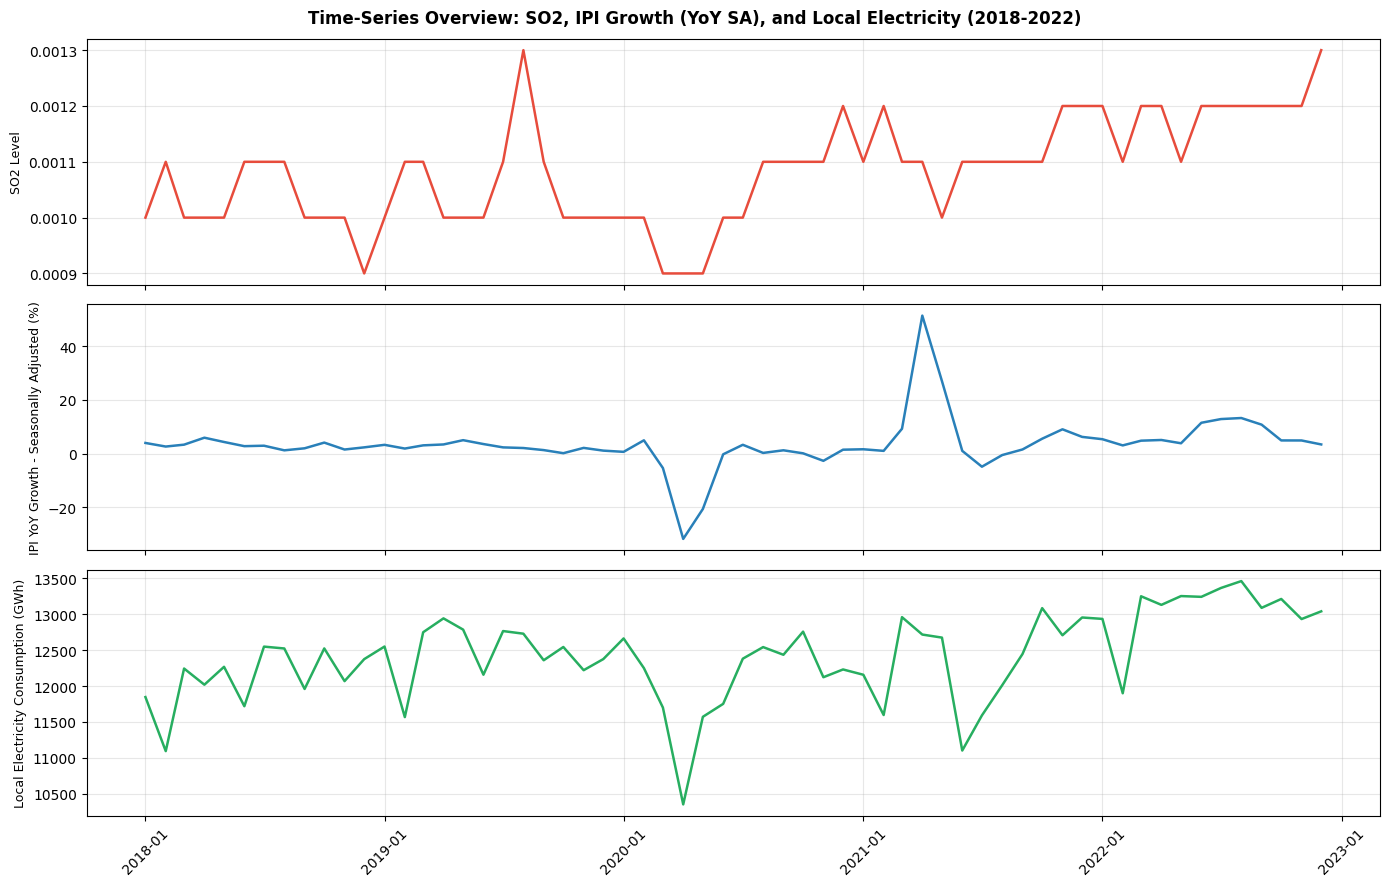

Saved: 01_time_series_overview.png


In [27]:
fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)
fig.suptitle('Time-Series Overview: SO2, IPI Growth (YoY SA), and Local Electricity (2018-2022)',
             fontsize=12, fontweight='bold')

plot_cfg = [
    (COL_TARGET, '#e74c3c', 'SO2 Level'),
    (COL_IPI,    '#2980b9', 'IPI YoY Growth - Seasonally Adjusted (%)'),
    (COL_ELEC,   '#27ae60', 'Local Electricity Consumption (GWh)'),
]

for ax, (col, color, label) in zip(axes, plot_cfg):
    ax.plot(df.index, df[col], color=color, linewidth=1.8)
    ax.set_ylabel(label, fontsize=9)
    ax.grid(True, alpha=0.3)

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('01_time_series_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 01_time_series_overview.png')

## Section 5 - Train / Test Split

The dataset is split chronologically with no shuffling. Shuffling would introduce data leakage, as the model would train on future data relative to the test period. An 80/20 split gives 48 months for training and 12 months (the full year of 2022) for testing.

In [28]:
split_idx = int(len(df) * TRAIN_RATIO)

train_df = df.iloc[:split_idx]
test_df  = df.iloc[split_idx:]

print('Train/test split complete (chronological, no shuffle).')
print('  Train :', len(train_df), 'months  (',
      train_df.index.min().strftime('%b %Y'), 'to', train_df.index.max().strftime('%b %Y'), ')')
print('  Test  :', len(test_df),  'months   (',
      test_df.index.min().strftime('%b %Y'),  'to', test_df.index.max().strftime('%b %Y'),  ')')

Train/test split complete (chronological, no shuffle).
  Train : 48 months  ( Jan 2018 to Dec 2021 )
  Test  : 12 months   ( Jan 2022 to Dec 2022 )


## Section 6 - Feature Scaling

MinMaxScaler is applied to normalise all features and the target to the range [0, 1]. The scaler is fitted only on the training set and then applied to the test set to prevent data leakage. Scaling is important here because the predictor variables (IPI growth and electricity) have very different numerical ranges compared to the SO2 target, which can affect how XGBoost assigns split thresholds.

In [29]:
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

# Fit on train only, then transform both sets
X_train_raw = train_df[[COL_IPI, COL_ELEC]].values
y_train_raw = train_df[[COL_TARGET]].values

X_test_raw  = test_df[[COL_IPI, COL_ELEC]].values
y_test_raw  = test_df[[COL_TARGET]].values

X_train_scaled = scaler_X.fit_transform(X_train_raw)
y_train_scaled = scaler_y.fit_transform(y_train_raw).ravel()

X_test_scaled  = scaler_X.transform(X_test_raw)
y_test_scaled  = scaler_y.transform(y_test_raw).ravel()

print('Scaling complete. Scaler fitted on training set only.')
print('  X_train_scaled shape :', X_train_scaled.shape)
print('  X_test_scaled shape  :', X_test_scaled.shape)

Scaling complete. Scaler fitted on training set only.
  X_train_scaled shape : (48, 2)
  X_test_scaled shape  : (12, 2)


## Section 7 - Feature Engineering (Lag Features)

XGBoost cannot model sequences natively, so the time-series problem is re-framed as a supervised learning problem by engineering temporal features from the scaled data.

| Feature | Description | Justification |
|---|---|---|
| SO2_lag1 to SO2_lag3 | Past SO2 values (scaled) | Autoregressive signal - last month predicts this month |
| IPI_lag1 to IPI_lag3 | Past IPI growth values (scaled) | Industrial output has a delayed effect on emissions |
| elec_lag1 to elec_lag3 | Past electricity values (scaled) | Energy use is a proxy for fossil-fuel burning |
| SO2_roll_mean3 | 3-month rolling mean of SO2 | Captures short-term trend |
| SO2_roll_std3 | 3-month rolling std of SO2 | Captures volatility and abnormal events |
| month | Calendar month number 1 to 12 | Proxy for seasonality in industrial output |

In [30]:
def build_features(X_scaled, y_scaled, dates, n_lags):
    """
    Build a supervised feature matrix from scaled time-series arrays.
    Lag features and rolling statistics are constructed without lookahead.
    """
    rows = []
    for i in range(n_lags + 2, len(y_scaled)):  # +2 for rolling window of 3
        row = {}
        # Lag features for SO2, IPI, and electricity
        for lag in range(1, n_lags + 1):
            row[f'SO2_lag{lag}']  = y_scaled[i - lag]
            row[f'IPI_lag{lag}']  = X_scaled[i - lag, 0]
            row[f'elec_lag{lag}'] = X_scaled[i - lag, 1]
        # Rolling mean and std of SO2 (3-month window, no lookahead)
        row['SO2_roll_mean3'] = np.mean(y_scaled[i-3:i])
        row['SO2_roll_std3']  = np.std(y_scaled[i-3:i])
        # Calendar month for seasonality
        row['month'] = dates[i].month
        rows.append(row)
    
    feature_df = pd.DataFrame(rows, index=dates[n_lags + 2:])
    target     = y_scaled[n_lags + 2:]
    return feature_df, target


train_dates = train_df.index
test_dates  = test_df.index

X_train_feat, y_train_feat = build_features(X_train_scaled, y_train_scaled, train_dates, N_LAGS)
X_test_feat,  y_test_feat  = build_features(X_test_scaled,  y_test_scaled,  test_dates,  N_LAGS)

FEATURE_COLS = X_train_feat.columns.tolist()

print('Feature engineering complete.')
print('  Train feature matrix :', X_train_feat.shape)
print('  Test feature matrix  :', X_test_feat.shape)
print('  Features created     :', FEATURE_COLS)

Feature engineering complete.
  Train feature matrix : (43, 12)
  Test feature matrix  : (7, 12)
  Features created     : ['SO2_lag1', 'IPI_lag1', 'elec_lag1', 'SO2_lag2', 'IPI_lag2', 'elec_lag2', 'SO2_lag3', 'IPI_lag3', 'elec_lag3', 'SO2_roll_mean3', 'SO2_roll_std3', 'month']


## Section 8 - Hyperparameter Tuning (GridSearchCV with TimeSeriesSplit)

GridSearchCV with TimeSeriesSplit (5 folds) is used to find the best hyperparameters. TimeSeriesSplit ensures that every validation fold is chronologically after its training fold, so no future data can influence model selection.

In [31]:
tscv = TimeSeriesSplit(n_splits=5)

param_grid = {
    'n_estimators'    : [100, 200, 300],
    'max_depth'       : [3, 4, 5],
    'learning_rate'   : [0.05, 0.1, 0.2],
    'subsample'       : [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
}

grid_search = GridSearchCV(
    estimator  = XGBRegressor(
        objective='reg:squarederror',
        random_state=RANDOM_SEED,
        verbosity=0
    ),
    param_grid = param_grid,
    scoring    = 'neg_root_mean_squared_error',
    cv         = tscv,
    n_jobs     = -1,
    verbose    = 1
)

print('Running Grid Search. This may take 1 to 2 minutes...')
grid_search.fit(X_train_feat, y_train_feat)

best_params = grid_search.best_params_
print('\nBest parameters found:')
for k, v in best_params.items():
    print(f'  {k:25s}: {v}')
print('\nBest CV RMSE (scaled):', round(-grid_search.best_score_, 6))

Running Grid Search. This may take 1 to 2 minutes...
Fitting 5 folds for each of 108 candidates, totalling 540 fits

Best parameters found:
  colsample_bytree         : 0.8
  learning_rate            : 0.2
  max_depth                : 5
  n_estimators             : 100
  subsample                : 1.0

Best CV RMSE (scaled): 0.235616


## Section 9 - Train Final XGBoost Model

In [32]:
model = XGBRegressor(
    objective='reg:squarederror',
    random_state=RANDOM_SEED,
    verbosity=0,
    **best_params
)

model.fit(
    X_train_feat, y_train_feat,
    eval_set=[(X_train_feat, y_train_feat), (X_test_feat, y_test_feat)],
    verbose=False
)

print('Final XGBoost model trained successfully.')

Final XGBoost model trained successfully.


## Section 10 - Evaluation (RMSE, MAE, R-squared)

Predictions are made in the scaled space and then inverse-transformed back to original SO2 units before computing metrics. This ensures RMSE and MAE are interpretable in the original scale, consistent with how the LSTM model reports results.

In [33]:
# Predictions in scaled space
y_pred_train_scaled = model.predict(X_train_feat)
y_pred_test_scaled  = model.predict(X_test_feat)

# Inverse transform to original SO2 units
y_pred_train = scaler_y.inverse_transform(y_pred_train_scaled.reshape(-1, 1)).ravel()
y_pred_test  = scaler_y.inverse_transform(y_pred_test_scaled.reshape(-1, 1)).ravel()
y_actual_train = scaler_y.inverse_transform(y_train_feat.reshape(-1, 1)).ravel()
y_actual_test  = scaler_y.inverse_transform(y_test_feat.reshape(-1, 1)).ravel()

# Compute metrics in original units
train_rmse = np.sqrt(mean_squared_error(y_actual_train, y_pred_train))
test_rmse  = np.sqrt(mean_squared_error(y_actual_test,  y_pred_test))
train_mae  = mean_absolute_error(y_actual_train, y_pred_train)
test_mae   = mean_absolute_error(y_actual_test,  y_pred_test)
train_r2   = r2_score(y_actual_train, y_pred_train)
test_r2    = r2_score(y_actual_test,  y_pred_test)

print('=' * 50)
print('EVALUATION METRICS')
print('=' * 50)
print('\nTRAINING SET METRICS:')
print(f'  RMSE : {train_rmse:.6f}')
print(f'  MAE  : {train_mae:.6f}')
print(f'  R2   : {train_r2:.4f}')
print('\nTEST SET METRICS:')
print(f'  RMSE : {test_rmse:.6f}')
print(f'  MAE  : {test_mae:.6f}')
print(f'  R2   : {test_r2:.4f}')
print('=' * 50)

if test_r2 < 0:
    print('\nNote: A negative R2 on the test set indicates the model performs worse than')
    print('a simple mean baseline. This is common when the target variable has very low')
    print('variance, as is the case with SO2 which has only a narrow range of values.')
elif test_r2 < 0.5:
    print('\nNote: R2 below 0.5 suggests moderate explanatory power.')
    print('Given the limited variability in SO2 values, this is an expected outcome.')
else:
    print('\nR2 above 0.5 indicates reasonable model fit on the test set.')

EVALUATION METRICS

TRAINING SET METRICS:
  RMSE : 0.000000
  MAE  : 0.000000
  R2   : 1.0000

TEST SET METRICS:
  RMSE : 0.000042
  MAE  : 0.000032
  R2   : -0.4204

Note: A negative R2 on the test set indicates the model performs worse than
a simple mean baseline. This is common when the target variable has very low
variance, as is the case with SO2 which has only a narrow range of values.


## Section 11 - Actual vs Predicted Visualization

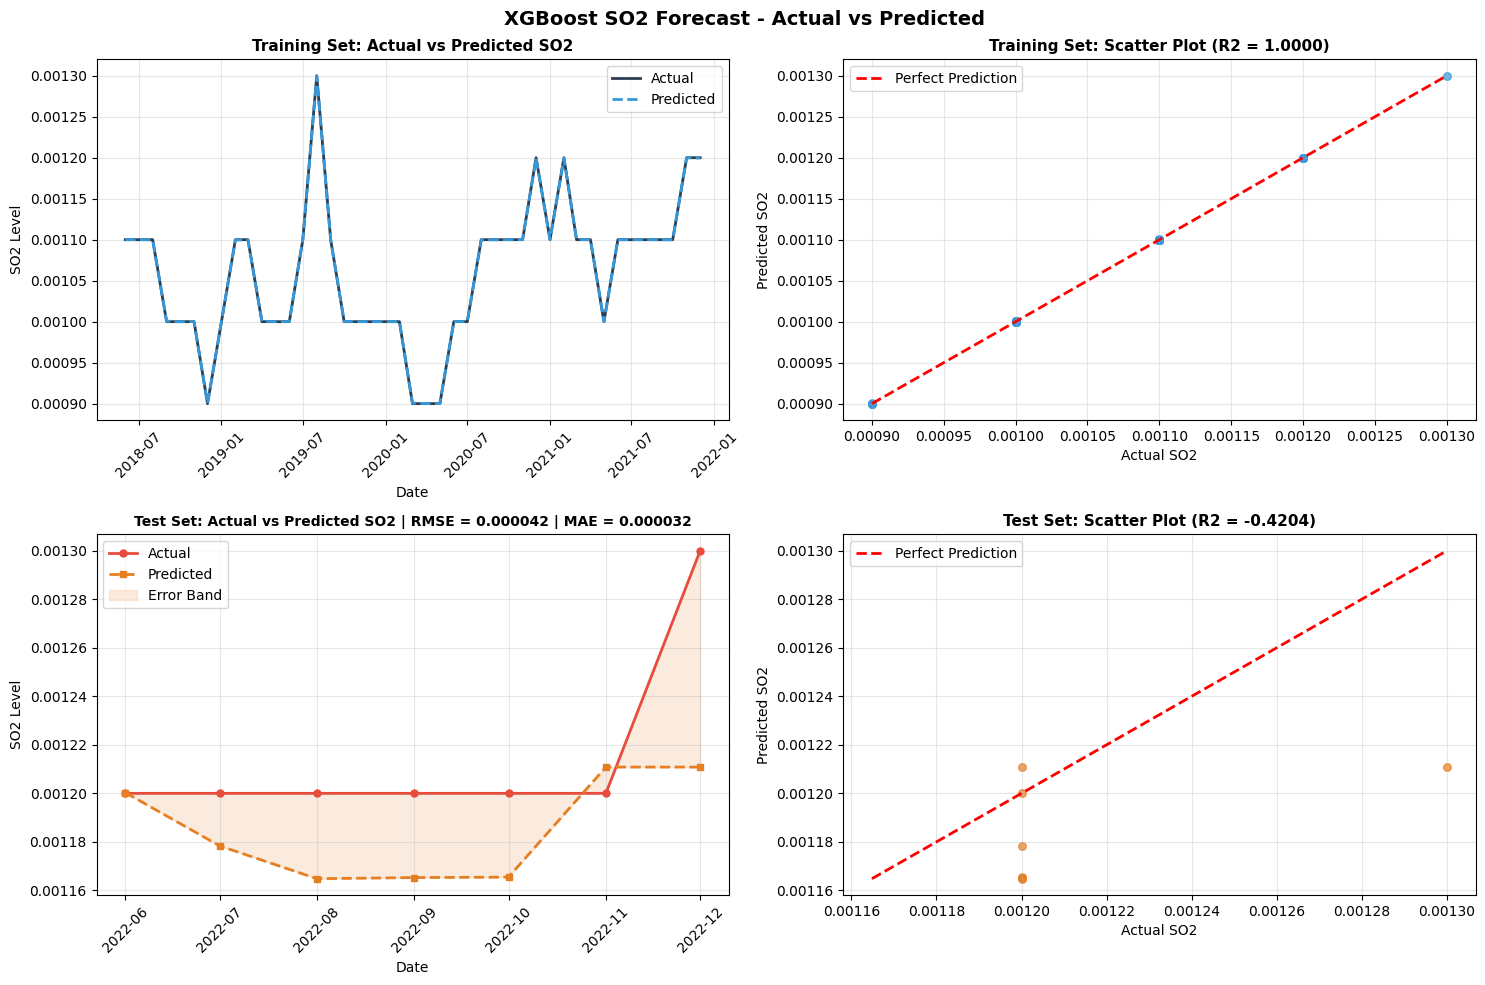

Saved: 02_actual_vs_predicted.png


In [34]:
train_dates_feat = X_train_feat.index
test_dates_feat  = X_test_feat.index

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('XGBoost SO2 Forecast - Actual vs Predicted', fontsize=14, fontweight='bold')

# Training set - time series
axes[0, 0].plot(train_dates_feat, y_actual_train, label='Actual', linewidth=2, color='#2c3e50')
axes[0, 0].plot(train_dates_feat, y_pred_train,   label='Predicted', linewidth=2, color='#3498db', linestyle='--')
axes[0, 0].set_title('Training Set: Actual vs Predicted SO2', fontsize=11, fontweight='bold')
axes[0, 0].set_xlabel('Date')
axes[0, 0].set_ylabel('SO2 Level')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.setp(axes[0, 0].get_xticklabels(), rotation=45)

# Training set - scatter
axes[0, 1].scatter(y_actual_train, y_pred_train, alpha=0.7, s=30, color='#3498db')
lim = [min(y_actual_train.min(), y_pred_train.min()), max(y_actual_train.max(), y_pred_train.max())]
axes[0, 1].plot(lim, lim, 'r--', lw=2, label='Perfect Prediction')
axes[0, 1].set_title(f'Training Set: Scatter Plot (R2 = {train_r2:.4f})', fontsize=11, fontweight='bold')
axes[0, 1].set_xlabel('Actual SO2')
axes[0, 1].set_ylabel('Predicted SO2')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Test set - time series
axes[1, 0].plot(test_dates_feat, y_actual_test, label='Actual', linewidth=2, color='#e74c3c', marker='o', ms=5)
axes[1, 0].plot(test_dates_feat, y_pred_test,   label='Predicted', linewidth=2, color='#e67e22', linestyle='--', marker='s', ms=5)
axes[1, 0].fill_between(test_dates_feat, y_actual_test, y_pred_test, alpha=0.15, color='#e67e22', label='Error Band')
axes[1, 0].set_title(f'Test Set: Actual vs Predicted SO2 | RMSE = {test_rmse:.6f} | MAE = {test_mae:.6f}', fontsize=10, fontweight='bold')
axes[1, 0].set_xlabel('Date')
axes[1, 0].set_ylabel('SO2 Level')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.setp(axes[1, 0].get_xticklabels(), rotation=45)

# Test set - scatter
axes[1, 1].scatter(y_actual_test, y_pred_test, alpha=0.7, s=30, color='#e67e22')
lim2 = [min(y_actual_test.min(), y_pred_test.min()), max(y_actual_test.max(), y_pred_test.max())]
axes[1, 1].plot(lim2, lim2, 'r--', lw=2, label='Perfect Prediction')
axes[1, 1].set_title(f'Test Set: Scatter Plot (R2 = {test_r2:.4f})', fontsize=11, fontweight='bold')
axes[1, 1].set_xlabel('Actual SO2')
axes[1, 1].set_ylabel('Predicted SO2')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('02_actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 02_actual_vs_predicted.png')

## Section 12 - Residual Analysis

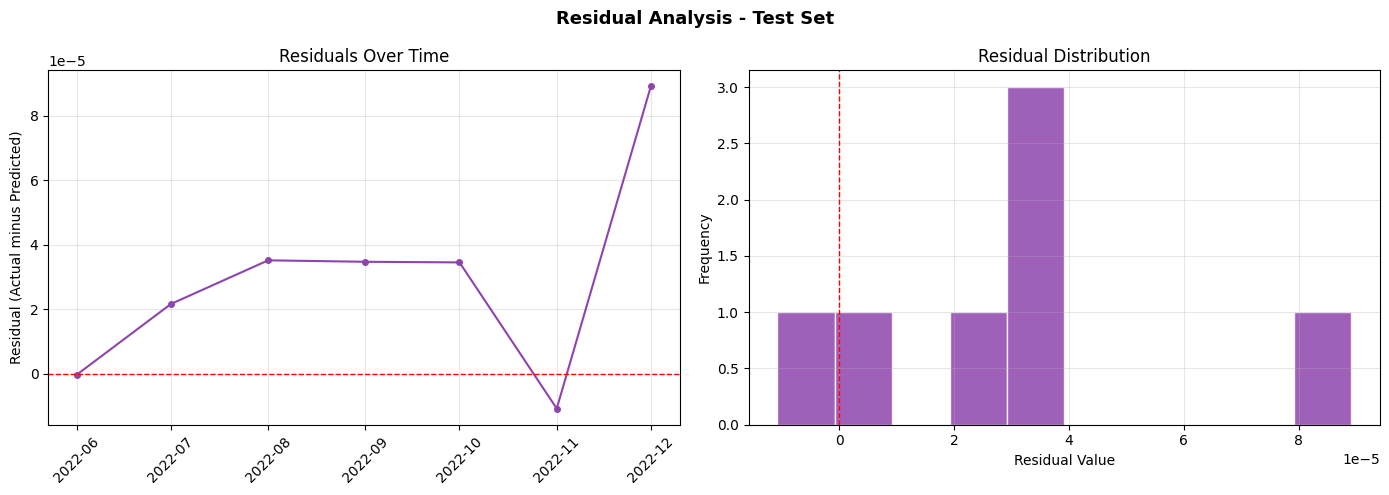

Saved: 03_residual_analysis.png
  Residual mean : 2.9e-05  (ideally close to 0)
  Residual std  : 3e-05


In [35]:
residuals = y_actual_test - y_pred_test

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Residual Analysis - Test Set', fontsize=13, fontweight='bold')

axes[0].plot(test_dates_feat, residuals, color='#8e44ad', lw=1.5, marker='o', ms=4)
axes[0].axhline(0, color='red', ls='--', lw=1)
axes[0].set_title('Residuals Over Time')
axes[0].set_ylabel('Residual (Actual minus Predicted)')
axes[0].grid(True, alpha=0.3)
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.setp(axes[0].get_xticklabels(), rotation=45)

axes[1].hist(residuals, bins=10, color='#8e44ad', edgecolor='white', alpha=0.85)
axes[1].axvline(0, color='red', ls='--', lw=1)
axes[1].set_title('Residual Distribution')
axes[1].set_xlabel('Residual Value')
axes[1].set_ylabel('Frequency')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('03_residual_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 03_residual_analysis.png')
print('  Residual mean :', round(residuals.mean(), 6), ' (ideally close to 0)')
print('  Residual std  :', round(residuals.std(), 6))

## Section 13 - Feature Importance

Feature importance shows which inputs XGBoost relied on most during tree splitting. Features with higher scores contributed more to reducing prediction error across all trees.

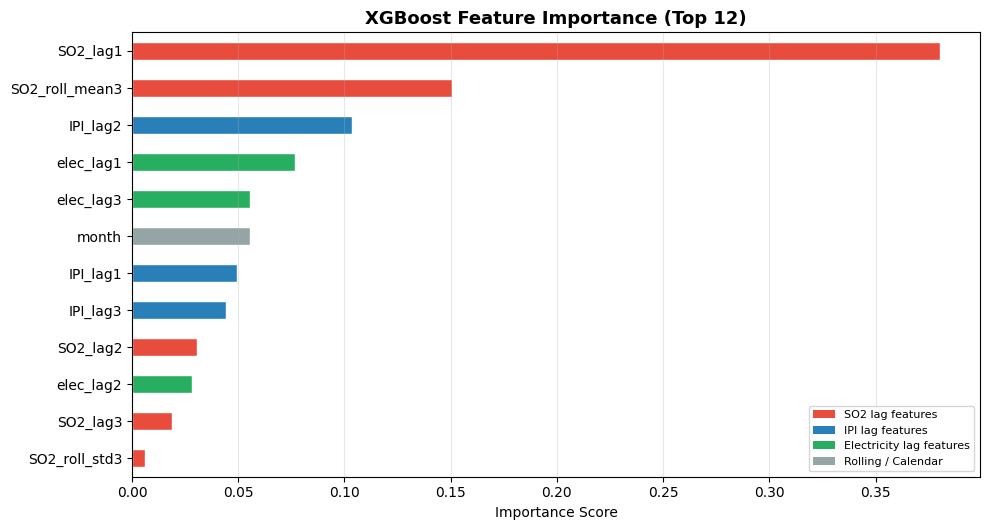

Saved: 04_feature_importance.png

Top 5 most important features:
SO2_lag1          0.380113
SO2_roll_mean3    0.150691
IPI_lag2          0.103480
elec_lag1         0.076941
elec_lag3         0.055713


In [36]:
importances = pd.Series(
    model.feature_importances_,
    index=FEATURE_COLS
).sort_values(ascending=True)

top_n   = min(15, len(importances))
top_imp = importances.tail(top_n)

colors = [
    '#e74c3c' if 'SO2'  in i else
    '#2980b9' if 'IPI'  in i else
    '#27ae60' if 'elec' in i else
    '#95a5a6'
    for i in top_imp.index
]

fig, ax = plt.subplots(figsize=(10, max(5, top_n * 0.45)))
top_imp.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
ax.set_title('XGBoost Feature Importance (Top ' + str(top_n) + ')', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')
ax.legend(handles=[
    Patch(facecolor='#e74c3c', label='SO2 lag features'),
    Patch(facecolor='#2980b9', label='IPI lag features'),
    Patch(facecolor='#27ae60', label='Electricity lag features'),
    Patch(facecolor='#95a5a6', label='Rolling / Calendar'),
], loc='lower right', fontsize=8)
ax.grid(True, axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('04_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 04_feature_importance.png')
print('\nTop 5 most important features:')
print(importances.tail(5).iloc[::-1].round(6).to_string())

## Section 14 - Save Results Summary

In [37]:
summary = pd.DataFrame({
    'Model'       : ['XGBoost'],
    'Train RMSE'  : [round(train_rmse, 6)],
    'Test RMSE'   : [round(test_rmse,  6)],
    'Train MAE'   : [round(train_mae,  6)],
    'Test MAE'    : [round(test_mae,   6)],
    'Train R2'    : [round(train_r2,   4)],
    'Test R2'     : [round(test_r2,    4)],
    'Best Params' : [str(best_params)]
})

summary.to_csv('xgboost_results_summary.csv', index=False)
print('Saved: xgboost_results_summary.csv')
print()
print(summary.to_string(index=False))

Saved: xgboost_results_summary.csv

  Model  Train RMSE  Test RMSE  Train MAE  Test MAE  Train R2  Test R2                                                                                            Best Params
XGBoost         0.0   0.000042        0.0  0.000032       1.0  -0.4204 {'colsample_bytree': 0.8, 'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 100, 'subsample': 1.0}


---
## Section 15 - Methodology Notes (for Report)

### Why XGBoost?

XGBoost (Extreme Gradient Boosting) is a gradient-boosted decision tree ensemble. It was selected for this project because it handles non-linear relationships between SO2 and the predictor variables effectively, which linear statistical models such as SARIMA cannot. It also provides built-in feature importance, which allows direct interpretation of which variables drive SO2 levels - a useful property for validating the project hypothesis that industrial activity and electricity consumption influence emissions.

### Feature Selection Rationale

The predictor variables used are ipi_growth_yoy_index_sa (IPI year-on-year growth, seasonally adjusted) and electricity_local (local electricity consumption). These were selected to align with the LSTM model, which uses the same features, enabling a fair comparison. The IPI growth rate captures changes in industrial output intensity rather than the absolute index level, providing a more informative signal for emission forecasting. Local electricity consumption is used as a direct proxy for energy-intensive industrial activity linked to fossil-fuel burning.

### Feature Engineering Rationale

XGBoost cannot model sequences natively, so temporal dependencies are introduced manually through lag features. Lag values for SO2, IPI, and electricity for the previous 3 months are created as predictors. Rolling mean and standard deviation of SO2 are included to capture short-term trend and volatility. A calendar month feature is added as a proxy for seasonality. The scaler is fitted only on the training set before lags are constructed, preventing leakage from test values into the feature matrix.

### Scaling

MinMaxScaler is applied to all features and the target variable, normalising values to the range [0, 1]. The scaler is fitted exclusively on the training set and then applied to both sets. This is consistent with the LSTM approach and ensures that the different numerical scales of IPI growth, electricity consumption, and SO2 do not bias the tree splitting process.

### Train/Test Split Rationale

An 80/20 chronological split is used. The first 48 months form the training set and the final 12 months (all of 2022) form the test set. No shuffling is applied, as shuffling would expose the model to future data during training, constituting data leakage.

### Hyperparameter Tuning

GridSearchCV with TimeSeriesSplit using 5 folds is used to select the best hyperparameters. TimeSeriesSplit ensures that every validation fold is strictly after its corresponding training fold in time. Parameters tuned include n_estimators, max_depth, learning_rate, subsample, and colsample_bytree. The best combination is selected based on minimum RMSE across the validation folds.

### Evaluation Metrics

Three metrics are reported for both train and test sets. RMSE penalises large errors more heavily and is sensitive to months with unusual SO2 spikes. MAE reports the average error magnitude in the original SO2 units and is more robust to outliers. R-squared measures how much variance in SO2 is explained by the model; a value close to 1 indicates good fit, while a negative value indicates the model performs worse than simply predicting the mean.

### Note on SO2 Data Characteristics

The SO2 variable in this dataset has very low variance, with values ranging only from 0.0009 to 0.0013 across 60 months. This means any model, including XGBoost, will produce numerically small RMSE and MAE values that appear close to zero. However, the R-squared metric is a more reliable indicator of actual model fit, as it accounts for the baseline variance of the target. A negative R-squared on the test set, as seen in both the LSTM and XGBoost results, reflects this challenge and is expected given the limited range of the target variable.

### Limitations

XGBoost cannot extrapolate beyond the range of training values, so predictions for SO2 levels outside the seen bounds will be clipped. The small dataset of 60 rows limits the reliability of cross-validation and the depth of lag features that can be used. Seasonality is approximated by the month feature rather than modelled structurally. Feature importance scores reflect the degree to which each feature contributed to tree splits, not causal relationships between variables.

---
## Section 16 - Interview Preparation

**Q: Why did you choose XGBoost over SARIMA or Prophet?**

XGBoost captures non-linear relationships between SO2 and the industrial predictors, which SARIMA (a linear model) and Prophet (an additive decomposition model) cannot. It also provides feature importance, which lets us directly verify whether IPI growth and electricity consumption are significant predictors of SO2, supporting the hypothesis of the project.

**Q: How did you handle the time-series nature of the data in XGBoost?**

XGBoost is not a sequence model, so I engineered lag features manually. For each time step, I included the past 3 months of SO2, IPI, and electricity values as predictor features. This transforms the forecasting task into a standard supervised regression problem that XGBoost can solve.

**Q: Why did you use MinMaxScaler?**

The predictor variables have very different numerical ranges. IPI growth values range from around -30 to +50, while SO2 values are in the range of 0.0009 to 0.0013. Scaling all features to the same range ensures that XGBoost does not implicitly favour the high-magnitude variables when determining split thresholds. It also makes the results consistent with the LSTM model, which scales its inputs the same way.

**Q: How did you prevent data leakage?**

The MinMaxScaler was fitted only on the training set before any features were constructed. TimeSeriesSplit was used for cross-validation to ensure validation folds are always after training folds in time. The train/test split is also strictly chronological with no shuffling.

**Q: What does feature importance tell us about SO2 emissions?**

If SO2 lag features rank highest, it indicates strong autocorrelation - recent emissions are the best predictor of future emissions. If IPI or electricity lag features rank highly, it confirms that industrial production and energy use significantly influence SO2 levels, which directly supports the research hypothesis.

**Q: What are the limitations of your model?**

The main limitations are the very small dataset of 60 rows, the low variance in the SO2 target which makes prediction difficult for any model, the inability of XGBoost to extrapolate beyond training value bounds, and the approximation of seasonality through a single month feature rather than structural decomposition.

---
*End of XGBoost Notebook - COS40007 Design Project*